Plot vorticity fields and energy spectra — Figures 1, 5, 6, 10, 18, 19

This notebook does:

1. Load a vorticity field `w(t,x,y)` from a NetCDF file (variable name: `w`).
2. Plot the vorticity field and energy spectrum at time t 

In [2]:
# ----------------------------
# Imports & configuration
# ----------------------------
from __future__ import annotations

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import jax_cfd.base as cfd
import jax_cfd.base.grids as grids
import jax_cfd.spectral as spectral

jax.config.update("jax_enable_x64", True)

In [15]:
# ----------------------------
# User knobs
# ----------------------------
INP = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/DNS.nc")   #where DNS is saved

ds = xr.open_dataset(INP)                #import DNS
time_index = 0
dt = float(ds.attrs["save_every"]) 

In [16]:
# ----------------------------
# Import the data
# ----------------------------
w = jnp.asarray(ds["w"].values)
Nt, Nx, Ny = w.shape
print(Nt, Nx, Ny)

50 2048 2048


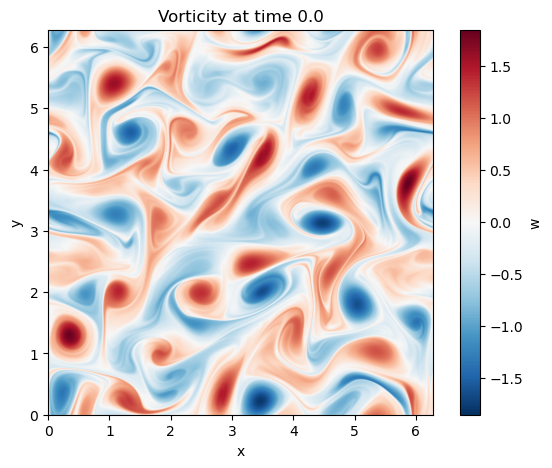

In [18]:
# ----------------------------
# Plot vorticity field
# ----------------------------
plt.figure(figsize=(7, 5))
vmax = np.max(np.abs(w[time_index,:,:]))
plt.imshow(w[time_index,:,:], origin="lower", cmap="RdBu_r",extent=[0, 2*np.pi, 0, 2*np.pi], vmin=-vmax, vmax=vmax)
plt.colorbar(label="w")
plt.title(f"Vorticity at time {time_index*dt}")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

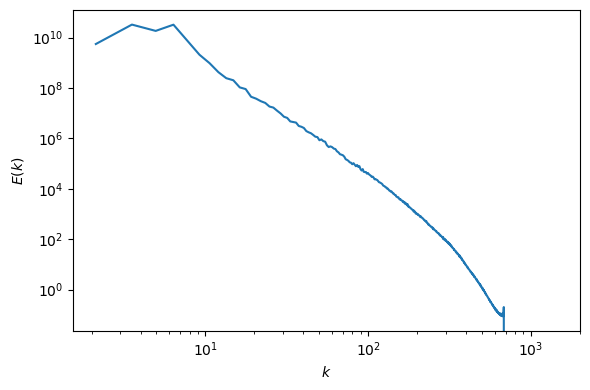

In [21]:
# ----------------------------
# Plot Energy Spectrum
# ----------------------------

w_plot_hat = jnp.fft.rfftn(w[time_index,:,:],axes=(0,1))
omega_hat_last = w_plot_hat  # (Nx, Ny//2+1)

Nx, Nyh = w_plot_hat.shape
Ny = 2 * (Nyh - 1)

# domain/grid
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
dx = Lx / Nx
dy = Ly / Ny

kx = 2.0 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)      # (Nx,)
ky = 2.0 * jnp.pi * jnp.fft.rfftfreq(Ny, d=dy)     # (Ny//2+1,)

KX = kx[:, None]
KY = ky[None, :]
K2 = KX**2 + KY**2
K = jnp.sqrt(K2)

K2_safe = jnp.where(K2 == 0, 1.0, K2)

psi_hat = -omega_hat_last / K2_safe
psi_hat = psi_hat.at[0, 0].set(0.0 + 0.0j)

u_hat = (1j * KY) * psi_hat
v_hat = (-1j * KX) * psi_hat

norm = (Nx * Ny)**2
Ehat = 0.5 * (jnp.abs(u_hat)**2 + jnp.abs(v_hat)**2)

w = jnp.ones((Nyh,), dtype=Ehat.dtype)
if Ny % 2 == 0 and Nyh >= 2:
    w = w.at[1:Nyh-1].set(2.0)   # interior doubled; endpoints unique
else:
    w = w.at[1:].set(2.0)        # only ky=0 unique

Ehat_w = Ehat * w[None, :]

K_np = np.asarray(K, dtype=np.float64)
E_np = np.asarray(Ehat_w, dtype=np.float64)

kmax = float(K_np.max())
nbins = int(min(Nx, Ny) // 2)
bins = np.linspace(0.0, kmax, nbins + 1)

k_flat = K_np.ravel()
E_flat = E_np.ravel()

Ek, _ = np.histogram(k_flat, bins=bins, weights=E_flat)
k_centers = 0.5 * (bins[:-1] + bins[1:])

# plot
plt.figure(figsize=(6,4))
plt.loglog(k_centers[1:], Ek[1:])
plt.xlabel(r"$k$")
plt.ylabel(r"$E(k)$")
plt.tight_layout()
plt.show()